## Overview

In this project, I applied supervised learning techniques to perform predictions using progressive dataset refinement, feature engineering, hyperparameter tuning, and XGBoost gradient-boosted decision trees. The analysis demonstrated XGBoost's strong predictive performance on structured data.
This work was completed as part of a Professional Certificate in Data Science with Machine Learning and AI from the University of Cambridge. Due to confidentiality requirements, I cannot share the dataset or complete project details, but I present the methodology and selected results that showcase the techniques learned during the course.

## Approach

All work in this project was implemented in Python 3.12.3. Datasets underwent preprocessing and EDA using pandas (v2.2.3). Irrelevant columns and high cardinality features were removed. "Date of Birth" was transformed into "Age." Columns with >50% missing data were dropped. Ordinal encoding was applied to the column with ordinal data using scikit-learn (v1.6.1) (Pedregosa et al., 2011). Absence counts were binned into categories. One-hot encoding was used for other categorical features. Missing values were addressed by removing observations when the fraction of NAs was below 2%. When needed, feature engineering techniques were applied to create new features that provided additional insights. NumPy (v1.26.4) was used for numerical computations.

#### Libraries required for this project include: 

In [5]:
#| echo: true
#| warning: false
#| message: false
#| echo-fold: true

# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.optimizers import Adam, RMSprop
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping
from keras.layers import Dense, Dropout, InputLayer
from keras import regularizers
import gc
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, auc,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve, ConfusionMatrixDisplay)

from tqdm import tqdm 
from itertools import product
import os
import random
import textwrap

import math
from scipy.stats import pearsonr, spearmanr, shapiro, levene, mannwhitneyu
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from datetime import date
from sklearn.pipeline import Pipeline
import xgboost as xgb
import shap
from xgboost import plot_importance
from sklearn.model_selection import GridSearchCV

In [10]:
#| echo: false
# Load data
df3 = pd.read_csv('assets/student_dropout/figures/student_dropout_data_stage_3.csv')

In [11]:
#| echo: false
#| output: false
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CentreName                25059 non-null  object 
 1   LearnerCode               25059 non-null  int64  
 2   BookingType               25059 non-null  object 
 3   LeadSource                25059 non-null  object 
 4   DiscountType              7595 non-null   object 
 5   DateofBirth               25059 non-null  object 
 6   Gender                    25059 non-null  object 
 7   Nationality               25059 non-null  object 
 8   HomeState                 8925 non-null   object 
 9   HomeCity                  21611 non-null  object 
 10  CourseLevel               25059 non-null  object 
 11  CourseName                25059 non-null  object 
 12  IsFirstIntake             25059 non-null  bool   
 13  CompletedCourse           25059 non-null  object 
 14  Assess

In [12]:
# Remove unnecessary columns
df3.drop('LearnerCode', axis=1, inplace=True)

### Remove columns with high cardinality (use >200 unique values, as a guideline for this data set).

High cardinality refers to columns that contain a large number of unique values. In this case the recommendation is to remove columns with >200 unique values. This may need adjustment based on specific dataset and analysis goals.
This is important because columns with high cardinality can lead to overfitting of machine learning models, creates sparse data when one-hot encoded significantly increasing memory usage.

In [13]:
# Get list of columns to remove
high_cardinality_cols_s3 = [col for col in df3.columns if df3[col].nunique() > 200]
print("High cardinality columns:", high_cardinality_cols_s3)

High cardinality columns: ['DateofBirth', 'HomeState', 'HomeCity', 'ProgressionDegree', 'UnauthorisedAbsenceCount']


HomeState and HomeCity are unlikely to provide any useful information regarding the student’s likelihood to drop out. So they will be remove from the dataset considering their high cardinality.

DateOfBirth will also be removed due to its high cardinality. However, first I will create a new column called Age which will be the difference between the current date and the date of birth. This will be a more useful feature for the analysis.

ProgressionDegree will also be removed due to its high cardinality. This column contains 2616 unique values which is too high for encoding. Nonetheless, it is important to note that this column contains information about the degree the student is studying. This information may be useful for the analysis, but it is not possible to encode it in a meaningful way. 

UnauthorisedAbsenceCount will not be removed, but engineered instead. 

In [14]:
# Remove these columns
df3_reduced = df3.drop(columns=['HomeState', 'HomeCity'], axis=1)

In [15]:
# Convert DateofBirth to Age

df3_reduced['DateofBirth'] = pd.to_datetime(df3_reduced['DateofBirth'], dayfirst=True, errors='coerce')

df3_reduced['Age'] = (date.today().year - df3_reduced['DateofBirth'].dt.year)

# Drop the original DateofBirth column
df3_reduced.drop('DateofBirth', axis=1, inplace=True)

In [16]:
display(df3_reduced.head())

,CentreName,BookingType,LeadSource,DiscountType,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age
0,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN,27
1,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,BSc Biological Sciences,University of Aberdeen,93.0,5.0,27
2,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,International Year Two,Business Management and Finance International ...,False,Yes,8.0,8.0,0.0,MA Finance,University of Aberdeen,92.0,6.0,25
3,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,International Year Two,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,MA Business Management,University of Aberdeen,67.0,15.0,26
4,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,MSc International Business Management,University of Aberdeen,NaN,NaN,29


In [17]:
# Drop the ProgressionDegree column
df3_reduced.drop('ProgressionDegree', axis=1, inplace=True)

#### Based on analysis performed for Stage 2 data, UnauthorisedAbsenceCount and AuthorisedAbsenceCount were transformed into categories by binning. 

In [18]:
# Define bins (adjust thresholds based on domain knowledge)
bins = [0, 10, 50, 100, float('inf')]
labels = ['<10', '11-50', '51-100', '>100']

# Create a new binned column
df3_reduced['Unauthorised_AbsenceCategory'] = pd.cut(
    df3_reduced['UnauthorisedAbsenceCount'],
    bins=bins,
    labels=labels,
    right=False
)

In [19]:
display(df3_reduced.head(2))

,CentreName,BookingType,LeadSource,DiscountType,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age,Unauthorised_AbsenceCategory
0,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,University of Aberdeen,NaN,NaN,27,NaN
1,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,University of Aberdeen,93.0,5.0,27,<10


#### Now we can drop UnauthorisedAbsenceCount

In [20]:
# Drop the ProgressionDegree column
df3_reduced.drop('UnauthorisedAbsenceCount', axis=1, inplace=True)

#### Repeat the binning process for the AuthorisedAbsenceCount to keep it consistent

In [21]:
# Define bins (adjust thresholds based on domain knowledge)
bins = [0, 10, 50, 100, float('inf')]
labels = ['<10', '11-50', '51-100', '>100']

# Create a new binned column
df3_reduced['Autorised_AbsenceCategory'] = pd.cut(
    df3_reduced['AuthorisedAbsenceCount'],
    bins=bins,
    labels=labels,
    right=False
)

In [22]:
# Drop the ProgressionDegree column
df3_reduced.drop('AuthorisedAbsenceCount', axis=1, inplace=True)

### Remove columns with > 50% data missing.

In [23]:
# Get list of columns to remove
high_nas_cols_s3 = [col for col in df3_reduced.columns if df3_reduced[col].isna().sum() > 0.5 * len(df3_reduced)]
print("High NA columns:", high_nas_cols_s3)

High NA columns: ['DiscountType']


In [24]:
# Drop the DiscountType column
df3_reduced.drop('DiscountType', axis=1, inplace=True)

In [25]:
display(df3_reduced.head(2))

,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionUniversity,Age,Unauthorised_AbsenceCategory,Autorised_AbsenceCategory
0,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,University of Aberdeen,27,NaN,NaN
1,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,University of Aberdeen,27,<10,51-100


#### Check new Features

In [26]:
# Check number of unique values in new features
print("Unique values in AssessedModules:", df3_reduced['AssessedModules'].nunique())
print("Count of each unique value in AssessedModules:")
print(df3_reduced['AssessedModules'].value_counts())

print("Unique values in PassedModules:", df3_reduced['PassedModules'].nunique())
print("Count of each unique value in PassedModules:")
print(df3_reduced['PassedModules'].value_counts())

print("Unique values in FailedModules:", df3_reduced['FailedModules'].nunique())
print("Count of each unique value in FailedModules:")
print(df3_reduced['FailedModules'].value_counts())

Unique values in AssessedModules: 12
Count of each unique value in AssessedModules:
AssessedModules
6.0     6426
4.0     4749
7.0     3858
8.0     3805
5.0     1384
9.0      958
3.0      521
10.0     439
1.0      308
2.0      217
11.0     161
12.0       2
Name: count, dtype: int64
Unique values in PassedModules: 12
Count of each unique value in PassedModules:
PassedModules
6.0     5858
4.0     4301
7.0     3673
8.0     3555
0.0     1536
5.0     1099
9.0      816
3.0      650
1.0      441
2.0      426
10.0     342
11.0     131
Name: count, dtype: int64
Unique values in FailedModules: 11
Count of each unique value in FailedModules:
FailedModules
0.0     18598
1.0      1514
3.0       710
2.0       658
4.0       589
5.0       469
6.0       184
7.0        58
8.0        28
9.0        11
10.0        9
Name: count, dtype: int64


#### Examine features with NAs more in detail.

In [27]:
# Create DataFrame with only rows containing NA values
na_rows_df = df3_reduced[df3_reduced.isna().any(axis=1)]

# Show summary of NA rows
print(f"Found {len(na_rows_df)} rows with missing values")
display(na_rows_df.head())

# Optional: Show which columns have NAs in these rows
print("\nColumns with NAs in these rows:")
print(na_rows_df.isna().sum()[na_rows_df.isna().sum() > 0])

Found 2310 rows with missing values


,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionUniversity,Age,Unauthorised_AbsenceCategory,Autorised_AbsenceCategory
0,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,University of Aberdeen,27,NaN,NaN
4,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,University of Aberdeen,29,NaN,NaN
6,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Foundation,Business; Economics; Accounting and Real Estat...,False,No,NaN,NaN,NaN,University of Aberdeen,23,11-50,11-50
17,ISC_Aberdeen,Direct,Sponsor,Male,Iraqi,Pre-Masters,Science and Engineering Pre-Masters,True,Yes,4.0,4.0,0.0,University of Aberdeen,27,NaN,NaN
36,ISC_Aberdeen,Direct,Digital (Web),Male,Indian,Pre-Masters,Science and Engineering Pre-Masters,True,Yes,4.0,4.0,0.0,University of Aberdeen,30,NaN,NaN



Columns with NAs in these rows:
AssessedModules                 2231
PassedModules                   2231
FailedModules                   2231
Unauthorised_AbsenceCategory     208
Autorised_AbsenceCategory        208
dtype: int64


#### Remove NAs from Unauthorised_AbsenceCategory, Autorised_AbsenceCategory only, because the fraction in these features is very small. Therefore their removal is unlikely to affect negatively the performance of the models.

In [28]:
# Check shape of original dataframe
print("Original shape:", df3_reduced.shape)

# Drop rows with NAs ONLY in the specified absence categories
cols_to_check = ['Unauthorised_AbsenceCategory', 'Autorised_AbsenceCategory']
df3_encoded_clean = df3_reduced.dropna(subset=cols_to_check)

# Check shape of cleaned dataframe
print("Cleaned shape:", df3_encoded_clean.shape)

# Show how many rows were dropped
rows_dropped = df3_reduced.shape[0] - df3_encoded_clean.shape[0]
print(f"Rows dropped (missing in absence categories): {rows_dropped}")

# Optional: Verify NAs still exist in other columns
print("\nRemaining NAs in other columns:")
print(df3_encoded_clean.isna().sum()[df3_encoded_clean.isna().sum() > 0])

Original shape: (25059, 16)
Cleaned shape: (24851, 16)
Rows dropped (missing in absence categories): 208

Remaining NAs in other columns:
AssessedModules    2102
PassedModules      2102
FailedModules      2102
dtype: int64


In [29]:
display(df3_encoded_clean.head(2))

,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionUniversity,Age,Unauthorised_AbsenceCategory,Autorised_AbsenceCategory
1,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,University of Aberdeen,27,<10,51-100
2,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,International Year Two,Business Management and Finance International ...,False,Yes,8.0,8.0,0.0,University of Aberdeen,25,<10,51-100


### Visualize the distribution of the new features

In [30]:
# Create a new df with only the new features for visualization purposes.
df3_view = df3_encoded_clean[['AssessedModules', 'PassedModules', 'FailedModules']]

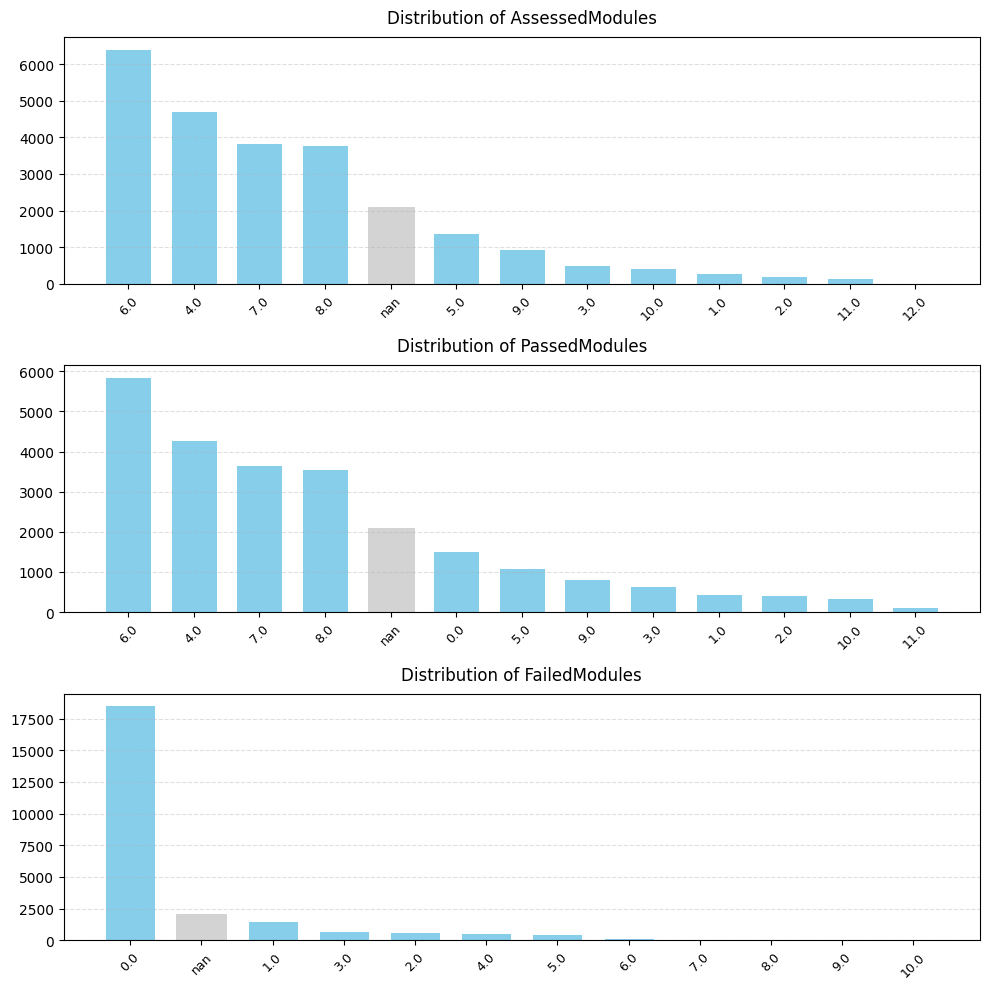

In [31]:
# @title: Data Distribution
def make_barplots(data, n_cols=1, n_rows=3, figsize=(10, 10), color='skyblue', 
                 na_color='lightgray', title_fontsize=12, label_fontsize=10, 
                 tick_label_fontsize=9, rotation=45, max_unique_cat=20, 
                 bar_width=0.7, grid=True, **kwargs):
    """
    Generate bar plots for categorical features in a DataFrame.
    
    Parameters:
        data: DataFrame or array-like
        n_cols: Number of columns in subplot grid
        ... [other params]
    """
    # Convert to DataFrame if numpy array
    if isinstance(data, np.ndarray):
        data = pd.DataFrame(data)
    
    # Select only categorical columns
    cat_cols = [col for col in data.columns 
               if data[col].dtype == 'object' or 
               data[col].nunique() <= max_unique_cat]
    
    # Calculate required rows if not specified
    if n_rows == 'auto':
        n_rows = int(np.ceil(len(cat_cols) / n_cols))
    
    # Create figure and axes grid
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    
    for i, (ax, column) in enumerate(zip(axes, cat_cols)):
        if i >= len(cat_cols):
            ax.axis('off')
            continue
            
        # Get value counts (including NA)
        value_counts = data[column].value_counts(dropna=False)
        
        # Plot bars
        x_pos = np.arange(len(value_counts))
        bars = ax.bar(x_pos, value_counts.values, 
                     width=bar_width, color=color, 
                     edgecolor='white', linewidth=0.7)
        
        # Customize plot
        ax.set_title(f'Distribution of {column}', fontsize=title_fontsize, pad=10)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(value_counts.index.astype(str), 
                         rotation=rotation,
                         fontsize=tick_label_fontsize)
        if grid:
            ax.grid(axis='y', linestyle='--', alpha=0.4)
        
        # Color NA bars differently
        if value_counts.index.isna().any():
            na_idx = np.where(value_counts.index.isna())[0]
            bars[na_idx[0]].set_color(na_color)
    
    plt.tight_layout()
    plt.show()
make_barplots(df3_view)

### Create feature RateModuleSuccess:  (PassedModules - FailedModules/ AssessedModules). This feature will provide a better measure of how well a student is performing in the courses.

- 2102 rows with NAs. This are 100% associated to the PassedModules, FailedModules, AssessedModules. 
- There seems to be a strong correlation between Dropout rate and the NAs in these features. Let's look at a correlation plot to confirm this.
- First, I will encode the data to make it easy to plot and calculate correlations.
  

### Perform ordinal encoding for ordinal data.

In [32]:
# Check the unique values in ordinal columns
for column in ['CourseLevel', 'Unauthorised_AbsenceCategory', 'Autorised_AbsenceCategory']:
    unique_values = df3_encoded_clean[column].unique()
    print(f"Unique values in {column}:")
    print(unique_values)
    print("\n" + "-"*50 + "\n")

Unique values in CourseLevel:
['Foundation' 'International Year Two' 'Pre-Masters'
 'International Year One']

--------------------------------------------------

Unique values in Unauthorised_AbsenceCategory:
['<10', '11-50', '51-100', '>100']
Categories (4, object): ['<10' < '11-50' < '51-100' < '>100']

--------------------------------------------------

Unique values in Autorised_AbsenceCategory:
['51-100', '11-50', '<10', '>100']
Categories (4, object): ['<10' < '11-50' < '51-100' < '>100']

--------------------------------------------------



In [33]:
# Convert ordinal columns to numeric using map
# Define the mapping for CourseLevel
course_level_mapping = {
    'Pre-Masters': 1,
    'Foundation': 2,
    'International Year One': 3,
    'International Year Two': 4
}
df3_encoded_clean['CourseLevel'] = df3_encoded_clean['CourseLevel'].map(course_level_mapping)


In [34]:
# For Unauthorised Absence
df3_encoded_clean['Unauthorised_Absence_Ordinal'] = (df3_encoded_clean['Unauthorised_AbsenceCategory'].cat.codes.replace({-1: np.nan}))

# For Authorised Absence
df3_encoded_clean['Autorised_Absence_Ordinal'] = (df3_encoded_clean['Autorised_AbsenceCategory'].cat.codes.replace({-1: np.nan}))


In [35]:
# Drop the Unauthorised_Absence_Ordinal and Autorised_Absence_Ordinal
df3_encoded_clean.drop(['Unauthorised_AbsenceCategory', 'Autorised_AbsenceCategory'], axis=1, inplace=True)

In [36]:
display(df3_encoded_clean.head(5))

,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionUniversity,Age,Unauthorised_Absence_Ordinal,Autorised_Absence_Ordinal
1,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,2,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,University of Aberdeen,27,0,2
2,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,4,Business Management and Finance International ...,False,Yes,8.0,8.0,0.0,University of Aberdeen,25,0,2
3,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,4,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,University of Aberdeen,26,1,2
5,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,4,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,University of Aberdeen,25,0,2
6,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,2,Business; Economics; Accounting and Real Estat...,False,No,NaN,NaN,NaN,University of Aberdeen,23,1,1


#### The dataset is heavily imbalanced with many of the features presenting few observations overrepresented within each feature. The target feature 'CompletedCourse' shows a ratio of 9:1 between two classes. One option would be to use SMOTE to balance the dataset, but since it is not clear what would be the effect of using synthetic data on the model, I will keep the dataset as it is for now.

#### EDA for stage 1 showed that the Nationality features is heavily skewed to two nationalities with Chinese representing 36.08% of the students and Bangladeshi representing another 8.01%, which is a very high proportion considering that there are 151 nationalities in the dataset. For this reason, this features was finally dropped from the dataset.

#### Nationality is heavily imbalanced with the Chinese students representing a 36.08% of the dataset, followed by the Bangladeshi students representing an 8.01%. The other 149 nationalities in the dataset represent the remaining 55.91% of the dataset. This is a very high imbalance and it is likely that this feature will not be useful for the analysis, so I will drop it.

In [37]:
# Create new dataframe without the Nationality column
df3_encoded_clean = df3_encoded_clean.drop(columns=['Nationality'], axis=1, inplace=False)

### Create new feature RateModuleSuccess, which combines the information contained in PassedModules, FailedModules and AssessedModules. By doing this we get to reduce the number of features in the dataset and use a new feature that provides a better relationship of students dropout vs success in class.

In [38]:
# Calculate RateModuleSuccess
df3_encoded_clean['RateModuleSuccess'] = (df3_encoded_clean['PassedModules'] - df3_encoded_clean['FailedModules']) / df3_encoded_clean['AssessedModules']

# Handle potential division by zero (if AssessedModules is 0)
df3_encoded_clean['RateModuleSuccess'] = df3_encoded_clean['RateModuleSuccess'].replace([np.inf, -np.inf], np.nan)

In [39]:
display(df3_encoded_clean.head(5))

,CentreName,BookingType,LeadSource,Gender,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionUniversity,Age,Unauthorised_Absence_Ordinal,Autorised_Absence_Ordinal,RateModuleSuccess
1,ISC_Aberdeen,Agent,Standard Agent Booking,Male,2,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,University of Aberdeen,27,0,2,1.0
2,ISC_Aberdeen,Agent,Standard Agent Booking,Male,4,Business Management and Finance International ...,False,Yes,8.0,8.0,0.0,University of Aberdeen,25,0,2,1.0
3,ISC_Aberdeen,Agent,Standard Agent Booking,Male,4,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,University of Aberdeen,26,1,2,1.0
5,ISC_Aberdeen,Agent,Standard Agent Booking,Male,4,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,University of Aberdeen,25,0,2,1.0
6,ISC_Aberdeen,Agent,Standard Agent Booking,Male,2,Business; Economics; Accounting and Real Estat...,False,No,NaN,NaN,NaN,University of Aberdeen,23,1,1,NaN


### Perform one-hot encoding for all other categorical data.

In [40]:
# One-hot encode categorical variables
def one_hot_encode(df, columns):
    return pd.get_dummies(df, columns=columns, drop_first=True, dtype=int)
# Define the columns to one-hot encode
one_hot_columns = ['CentreName', 'BookingType', 'LeadSource', 'Gender', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'ProgressionUniversity']

one_hot_encoded_df3 = one_hot_encode(df3_encoded_clean, one_hot_columns)
# Display the first few rows of the one-hot encoded DataFrame
display(one_hot_encoded_df3.head())
print("Shape of the one-hot encoded DataFrame:", df3_encoded_clean.shape)

,CourseLevel,AssessedModules,PassedModules,FailedModules,Age,Unauthorised_Absence_Ordinal,Autorised_Absence_Ordinal,RateModuleSuccess,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
1,2,7.0,7.0,0.0,27,0,2,1.0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,4,8.0,8.0,0.0,25,0,2,1.0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,4,8.0,8.0,0.0,26,1,2,1.0,0,0,...,0,1,0,0,0,0,0,0,0,0
5,4,8.0,8.0,0.0,25,0,2,1.0,0,0,...,0,1,0,0,0,0,0,0,0,0
6,2,NaN,NaN,NaN,23,1,1,NaN,0,0,...,0,1,0,0,0,0,0,0,0,0


Shape of the one-hot encoded DataFrame: (24851, 16)


In [41]:
# Check for missing values in the one-hot encoded DataFrame
missing_values = one_hot_encoded_df3.isnull().sum()
missing_values = missing_values[missing_values > 0]
if missing_values.empty:
    print("No missing values in one-hot encoded DataFrame.")
else:
    print("Missing values in one-hot encoded DataFrame:")
    print(missing_values)

    # Calculate percentage of missing values in each column
    missing_percentage = one_hot_encoded_df3.isnull().mean() * 100
    missing_percentage = missing_percentage[missing_percentage > 0]

    print("Percentage of missing values in each column:")
    print(missing_percentage)



Missing values in one-hot encoded DataFrame:
AssessedModules      2102
PassedModules        2102
FailedModules        2102
RateModuleSuccess    2102
dtype: int64
Percentage of missing values in each column:
AssessedModules      8.458412
PassedModules        8.458412
FailedModules        8.458412
RateModuleSuccess    8.458412
dtype: float64


#### Explore correlation between CompletedCourse vs features with NAs

In [42]:
# Create a new df with only the new features for visualization purposes. Note CompletedCourse is now CompletedCourse_Yes
df3_corr = one_hot_encoded_df3[['CompletedCourse_Yes', 'AssessedModules', 'PassedModules', 'FailedModules', 'RateModuleSuccess']]

# Create NA indicators for each column
na_analysis = df3_corr.assign(
    Assessed_NA = df3_corr['AssessedModules'].isna(),
    Passed_NA = df3_corr['PassedModules'].isna(),
    Failed_NA = df3_corr['FailedModules'].isna(),
    Rate_NA = df3_corr['RateModuleSuccess'].isna()
)

# Group by 'CompletedCourse_Yes' and sum NA counts (True=1, False=0)
na_counts = na_analysis.groupby('CompletedCourse_Yes')[['Assessed_NA', 'Passed_NA', 'Failed_NA', 'Rate_NA']].sum()

print("Raw NA counts by completion status (0=No, 1=Yes):")
print(na_counts)

Raw NA counts by completion status (0=No, 1=Yes):
                     Assessed_NA  Passed_NA  Failed_NA  Rate_NA
CompletedCourse_Yes                                            
0                           2102       2102       2102     2102
1                              0          0          0        0


#### This analysis confirms that all NAs are related to students that did not completed the course. Therefore, I think it is safe to turn those NAs into zeros in the new RateModuleSuccess feature. Also, safe to drop the the other 3 features 'AssessedModules', 'PassedModules', 'FailedModules'.

In [43]:
# Drop PassedModules, FailedModules, AssessedModules
one_hot_encoded_df3.drop(['PassedModules', 'FailedModules', 'AssessedModules'], axis=1, inplace=True)

In [44]:
# Covert NAs to 0s in RateModuleSuccess
# Replace NA with 0 ONLY in selected columns
df3_filled = one_hot_encoded_df3.copy()

df3_filled['RateModuleSuccess'] = one_hot_encoded_df3['RateModuleSuccess'].fillna(0)

# Calculate percentage of missing values in each column
missing_percentage = df3_filled.isnull().mean() * 100
missing_percentage = missing_percentage[missing_percentage > 0]

print("Percentage of missing values in each column:")
print(missing_percentage)

Percentage of missing values in each column:
Series([], dtype: float64)


In [45]:
# find column starting with CompletedCourse     
all_columns = [col for col in df3_filled.columns if col.startswith('CompletedCourse')]

# View in console (Jupyter/Colab shows full list)
print(all_columns) 

['CompletedCourse_Yes']


# Defining XGBoost Model: Stage 3

In [46]:
# Split the data into features and target variable
X_s3 = df3_filled.drop(columns=['CompletedCourse_Yes'], axis=1, inplace=False)
y_s3 = df3_filled['CompletedCourse_Yes']
# Display the first few rows of the features and target variable
display(X_s3.head())  

,CourseLevel,Age,Unauthorised_Absence_Ordinal,Autorised_Absence_Ordinal,RateModuleSuccess,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
1,2,27,0,2,1.0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,4,25,0,2,1.0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,4,26,1,2,1.0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
5,4,25,0,2,1.0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
6,2,23,1,1,0.0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [47]:
display(y_s3.head())

1    1
2    1
3    1
5    1
6    0
Name: CompletedCourse_Yes, dtype: int64

In [48]:
# Split the data into training and validation sets
X_train_s3, X_val_s3, y_train_s3, y_val_s3 = train_test_split(X_s3, y_s3, test_size=0.2, random_state=42)
# Split the training data into training and test sets
X_train_s3, X_test_s3, y_train_s3, y_test_s3 = train_test_split(X_train_s3, y_train_s3, test_size=0.2, random_state=42)

# Display the shapes of the training, validation, and test sets
print("Training set shape:", X_train_s3.shape, y_train_s3.shape)
print("Validation set shape:", X_val_s3.shape, y_val_s3.shape)
print("Test set shape:", X_test_s3.shape, y_test_s3.shape)
# Check the distribution of the target variable in the training set
print("Training set target variable distribution:")
print(y_train_s3.value_counts(normalize=True))
# Check the distribution of the target variable in the validation set
print("Validation set target variable distribution:")
print(y_val_s3.value_counts(normalize=True))
# Check the distribution of the target variable in the test set
print("Test set target variable distribution:")
print(y_test_s3.value_counts(normalize=True))

Training set shape: (15904, 241) (15904,)
Validation set shape: (4971, 241) (4971,)
Test set shape: (3976, 241) (3976,)
Training set target variable distribution:
CompletedCourse_Yes
1    0.855634
0    0.144366
Name: proportion, dtype: float64
Validation set target variable distribution:
CompletedCourse_Yes
1    0.853752
0    0.146248
Name: proportion, dtype: float64
Test set target variable distribution:
CompletedCourse_Yes
1    0.852616
0    0.147384
Name: proportion, dtype: float64


### XGBoost modelStage 3

In [49]:
#| eval: false
xg_model_no_tunning_s3 = xgb.XGBClassifier(random_state=42)
xg_model_no_tunning_s3.fit(X_train_s3, y_train_s3)

# Model evaluation
predictions_no_tunning_s3 = xg_model_no_tunning_s3.predict(X_val_s3)

# Calculate accuracy
accuracy = accuracy_score(y_val_s3, predictions_no_tunning_s3)

# Get classification report as dictionary
report = classification_report(y_val_s3, predictions_no_tunning_s3, output_dict=True)

# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

# Format the DataFrame
report_df = report_df.round(4)

# Reset index to make it a column with empty name
report_df = report_df.reset_index()
report_df.rename(columns={'index': ''}, inplace=True)

# Save to CSV
report_df.to_csv('xgboost_classification_report_no_tuning.csv', index=False)


# Add accuracy as a separate display
print(f"XGBoost Model Accuracy: {accuracy}\n")

# Display the classification report as a formatted table
# Format only numeric columns, leave the first column (class names) as-is
display(report_df.style.format({
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'f1-score': '{:.4f}',
    'support': '{:.0f}'
}, na_rep=''))

XGBoost Model Accuracy: 0.9710319855159928



,,precision,recall,f1-score,support
0,0,0.8934,0.9106,0.9019,727
1,1,0.9846,0.9814,0.9830,4244
2,accuracy,0.9710,0.9710,0.9710,1
3,macro avg,0.9390,0.9460,0.9425,4971
4,weighted avg,0.9713,0.9710,0.9711,4971


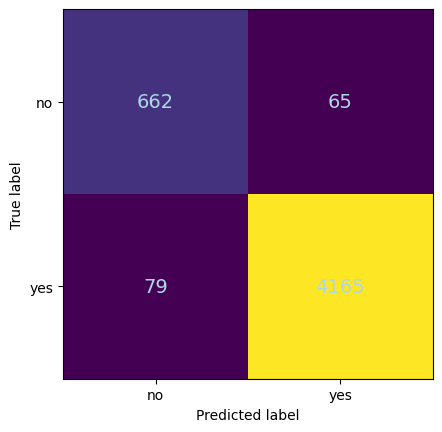

<Figure size 1000x600 with 0 Axes>

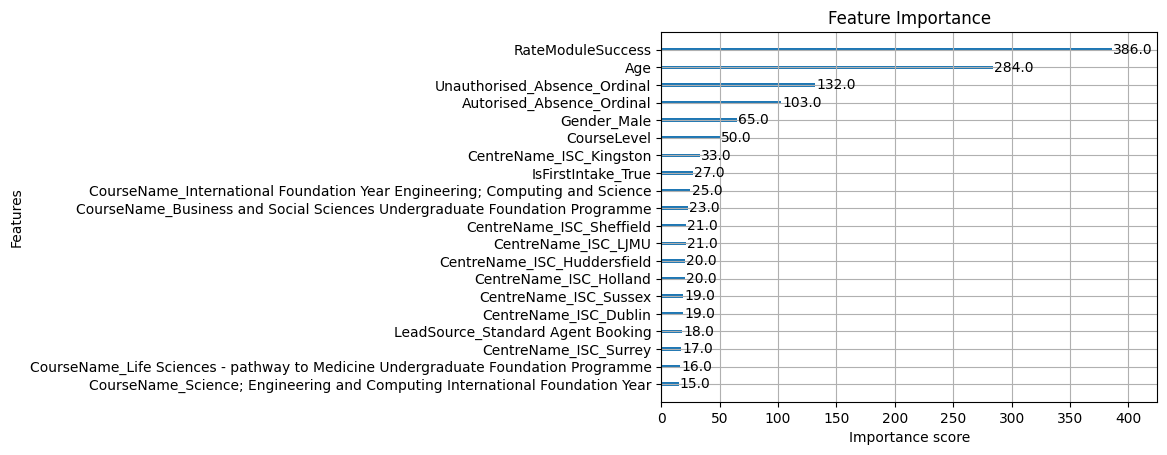

In [50]:
cm_no_tunning_s3 = confusion_matrix(y_val_s3, predictions_no_tunning_s3)
cfmd_no_tunning_s3 = ConfusionMatrixDisplay(confusion_matrix=cm_no_tunning_s3, display_labels=["no","yes"])
# Create plot and remove grid lines
fig, ax = plt.subplots()
cfmd_no_tunning_s3.plot(ax=ax, colorbar=False)
ax.grid(False)  # This removes the white crossing lines
# Make numbers more visible
for text in ax.texts:
    text.set_size(14)  # Larger font size
    text.set_color('lightblue')  # Force black text
plt.show()

# Feature Importance
plt.figure(figsize=(10, 6))
plot_importance(xg_model_no_tunning_s3, max_num_features=20)  # Top 20 features
plt.title('Feature Importance')
plt.show()

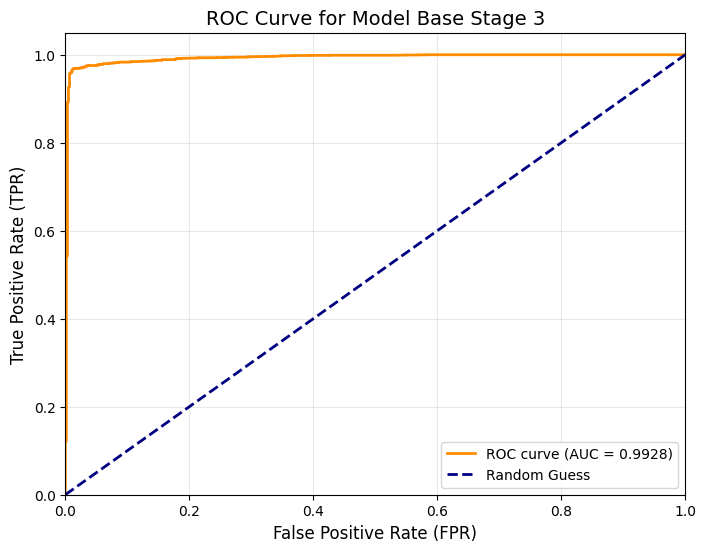

In [51]:
# @tittle Testing the model without tunning
# Calculate ROC curve using test set for better evaluation
y_pred_proba_no_tunning_s3 = xg_model_no_tunning_s3.predict_proba(X_test_s3)[:, 1]  # Probabilities for AUC using test set
fpr, tpr, thresholds = roc_curve(y_test_s3, y_pred_proba_no_tunning_s3) # Use TEST set for final evaluation
roc_auc_no_tunning_s3 = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc_no_tunning_s3:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve for Model Base Stage 3', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

### Fine Tunning with GridSearchCV.
#### The model will be trained using the training set and evaluated using the val set. 

In [52]:
# @title: Grid Search for Hyperparameter Tuning

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],      # Lower for better generalization
    'max_depth': [4, 6, 8],                   # Control tree complexity
    'min_child_weight': [1, 3, 5],            # Prevent overfitting
    'gamma': [0, 0.1, 0.2],                   # Regularization
    'subsample': [0.6, 0.8, 1.0],             # Stochastic sampling
    'colsample_bytree': [0.6, 0.8, 1.0],      # Feature sampling
    'n_estimators': [50, 100, 150]            # Number of trees
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(
        eval_metric='logloss',
        early_stopping_rounds=10,
        random_state=42
    ),
    param_grid=param_grid,
    scoring='roc_auc',  # Optimize for AUC
    cv=3,               # 3-fold cross-validation
    n_jobs=-1           # Use all CPU cores
)

grid_search.fit(X_train_s3, y_train_s3, eval_set=[(X_val_s3, y_val_s3)], verbose=False)
best_params_s3 = grid_search.best_params_

In [53]:
best_params_df_s3 = pd.DataFrame([best_params_s3])
display(best_params_df_s3)

,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,subsample
0,0.6,0.1,0.05,8,1,150,0.8


In [59]:
# Initialize model with optimized hyperparameters
xg_model_best_param_s3 = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,           # Number of boosting rounds
    max_depth=6,                # Tree depth
    learning_rate=0.1,          # Shrinkage factor
    subsample=0.8,              # % of samples per tree
    colsample_bytree=0.6,       # % of features per tree
    eval_metric='logloss',      # Metric for early stopping
    early_stopping_rounds=10,   # Stop if no improvement
    min_child_weight=1,        # Prevent overfitting
    gamma=0.1                  # Regularization
)

# Train with validation monitoring
xg_model_best_param_s3.fit(
    X_train_s3, y_train_s3,
    eval_set=[(X_val_s3, y_val_s3)],  # Early stopping data
    verbose=False                # Show training progress
)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6
,device,None
,early_stopping_rounds,10
,enable_categorical,False
,eval_metric,'logloss'


In [66]:
#| eval: false

# Model evaluation
predictions_best_param_s3 = xg_model_best_param_s3.predict(X_val_s3)

# Calculate accuracy
accuracy_best_param_s3 = accuracy_score(y_val_s3, predictions_best_param_s3)

# Get classification report as dictionary
report_df_best_param_s3 = classification_report(y_val_s3, predictions_best_param_s3, output_dict=True)

# Convert to DataFrame
report_df_best_param_s3 = pd.DataFrame(report_df_best_param_s3).transpose()

# Format the DataFrame
report_df_best_param_s3 = report_df_best_param_s3.round(4)

# Reset index to make it a column with empty name
report_df_best_param_s3 = report_df_best_param_s3.reset_index()
report_df_best_param_s3.rename(columns={'index': ''}, inplace=True)

# Save to CSV
report_df_best_param_s3.to_csv('assets/student_dropout/figures/xgboost_classification_report_best_param.csv', index=False)


# Add accuracy as a separate display
print(f"XGBoost Model Accuracy: {accuracy_best_param_s3}\n")

# Display the classification report as a formatted table
# Format only numeric columns, leave the first column (class names) as-is
display(report_df_best_param_s3.style.format({
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'f1-score': '{:.4f}',
    'support': '{:.0f}'
}, na_rep=''))

XGBoost Model Accuracy: 0.9712331522832428



,,precision,recall,f1-score,support
0,0,0.8893,0.9175,0.9032,727
1,1,0.9858,0.9804,0.9831,4244
2,accuracy,0.9712,0.9712,0.9712,1
3,macro avg,0.9376,0.9490,0.9431,4971
4,weighted avg,0.9717,0.9712,0.9714,4971


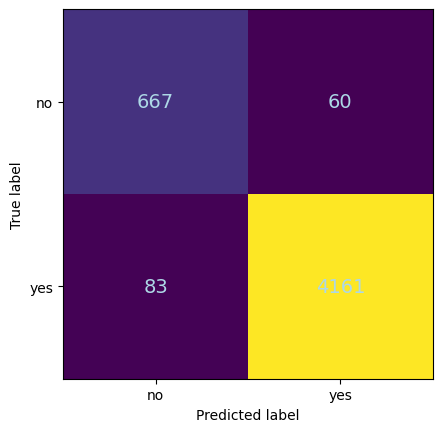

<Figure size 1000x600 with 0 Axes>

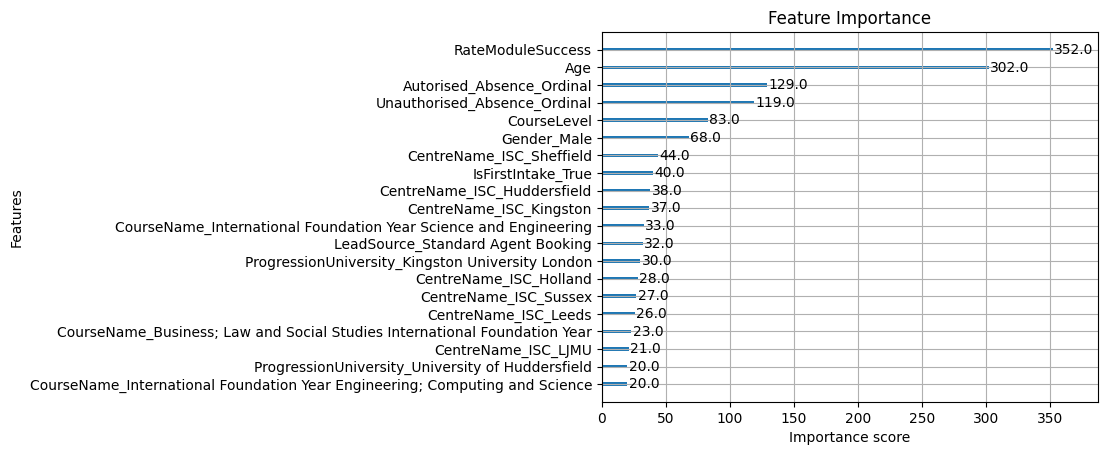

In [68]:
# Confusion Matrix
cm_best_param_s3 = confusion_matrix(y_val_s3, predictions_best_param_s3)
cfmd_best_param_s3 = ConfusionMatrixDisplay(confusion_matrix=cm_best_param_s3, display_labels=["no","yes"])
# Create plot and remove grid lines
fig, ax = plt.subplots()
cfmd_best_param_s3.plot(ax=ax, colorbar=False)
ax.grid(False)  # This removes the white crossing lines
# Make numbers more visible
for text in ax.texts:
    text.set_size(14)  # Larger font size
    text.set_color('lightblue')  # Force black text
plt.show()

# Feature Importance
plt.figure(figsize=(10, 6))
plot_importance(xg_model_best_param_s3, max_num_features=20)  # Top 20 features
plt.title('Feature Importance')
plt.show()

#### Testing the model on Testing data set for better reliability of results.

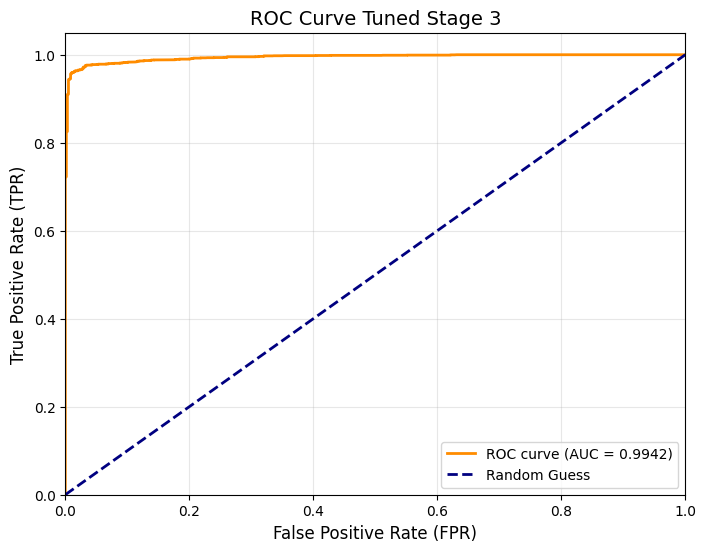

In [67]:
# @tittle Testing the model
# Calculate ROC curve
y_pred_proba_best_param_s3 = xg_model_best_param_s3.predict_proba(X_test_s3)[:, 1]  # Probabilities for AUC using test set
fpr, tpr, thresholds = roc_curve(y_test_s3, y_pred_proba_best_param_s3) # Use TEST set for final evaluation
roc_auc_best_param_s3 = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc_best_param_s3:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve Tuned Stage 3', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


### Comparison Models

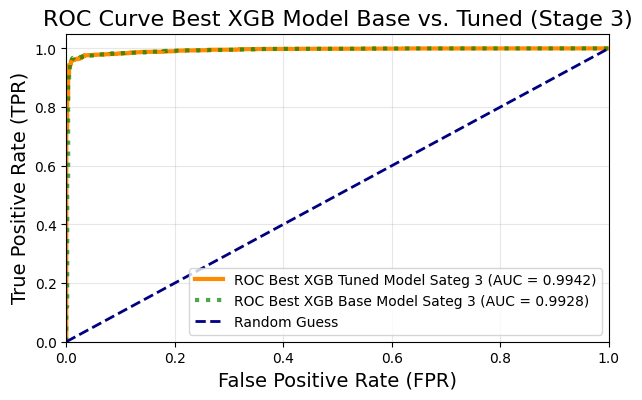

In [73]:

# Calculate ROC curve and AUC for the Base Model
y_pred_proba_base_s3 = xg_model_no_tunning_s3.predict_proba(X_test_s3)[:, 1]  # Probabilities for AUC using test set
fpr_base, tpr_base, thresholds_base = roc_curve(y_test_s3, y_pred_proba_base_s3) # Use TEST set for final evaluation
roc_auc_base_s3 = auc(fpr_base, tpr_base)

 # Calculate ROC curve and AUC for the Tuned Model
y_pred_proba_tuned_s3 = xg_model_best_param_s3.predict_proba(X_test_s3)[:, 1]  # Probabilities for AUC using test set
fpr_tuned, tpr_tuned, thresholds = roc_curve(y_test_s3, y_pred_proba_tuned_s3) # Use TEST set for final evaluation
roc_auc_tuned_s3 = auc(fpr_tuned, tpr_tuned)


# --- Plotting ---
plt.figure(figsize=(7, 4))

# Plot the Tuned Model's ROC Curve
plt.plot(fpr_tuned, tpr_tuned, color='darkorange', lw=3, alpha=1,
            label=f'ROC Best XGB Tuned Model Sateg 3 (AUC = {roc_auc_tuned_s3:.4f})')

# Plot the No Tuning Model's ROC Curve
plt.plot(fpr_base, tpr_base, color='green', lw=3, alpha=0.7, linestyle=':',
            label=f'ROC Best XGB Base Model Sateg 3 (AUC = {roc_auc_base_s3:.4f})')

# Plot the Random Guess line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

# --- Formatting the Plot ---
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title('ROC Curve Best XGB Model Base vs. Tuned (Stage 3)', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()





In [74]:
# For Untuned Model
precision_0_no_tuning_s3 = precision_score(y_val_s3, predictions_no_tunning_s3, average='binary', pos_label=0)
recall_0_no_tuning_s3 = recall_score(y_val_s3, predictions_no_tunning_s3, average='binary', pos_label=0)
f1_0_no_tuning_s3 = f1_score(y_val_s3, predictions_no_tunning_s3, average='binary', pos_label=0)

# For class 1 (Completed Course)
precision_1_no_tuning_s3 = precision_score(y_val_s3, predictions_no_tunning_s3, average='binary', pos_label=1) 
recall_1_no_tuning_s3 = recall_score(y_val_s3, predictions_no_tunning_s3, average='binary', pos_label=1)
f1_1_no_tuning_s3 = f1_score(y_val_s3, predictions_no_tunning_s3, average='binary', pos_label=1)

# Overall metrics for untuned model
accuracy_no_tuning_s3 = accuracy_score(y_val_s3, predictions_no_tunning_s3)
macro_precision_no_tuning_s3 = precision_score(y_val_s3, predictions_no_tunning_s3, average='macro')
macro_recall_no_tuning_s3 = recall_score(y_val_s3, predictions_no_tunning_s3, average='macro')
macro_f1_no_tuning_s3 = f1_score(y_val_s3, predictions_no_tunning_s3, average='macro')

roc_auc_no_tunning_s3 # Predictions probabilities for AUC were calculated earlier

# For Tuned Model
precision_0_best_param_s3 = precision_score(y_val_s3, predictions_best_param_s3, average='binary', pos_label=0)
recall_0_best_param_s3 = recall_score(y_val_s3, predictions_best_param_s3, average='binary', pos_label=0)
f1_0_best_param_s3 = f1_score(y_val_s3, predictions_best_param_s3, average='binary', pos_label=0)

# For class 1 (Completed Course)
precision_1_best_param_s3 = precision_score(y_val_s3, predictions_best_param_s3, average='binary', pos_label=1)
recall_1_best_param_s3 = recall_score(y_val_s3, predictions_best_param_s3, average='binary', pos_label=1)
f1_1_best_param_s3 = f1_score(y_val_s3, predictions_best_param_s3, average='binary', pos_label=1)

# Overall metrics for tuned model
accuracy_best_param_s3 = accuracy_score(y_val_s3, predictions_best_param_s3)
macro_precision_best_param_s3 = precision_score(y_val_s3, predictions_best_param_s3, average='macro')
macro_recall_best_param_s3 = recall_score(y_val_s3, predictions_best_param_s3, average='macro')
macro_f1_best_param_s3 = f1_score(y_val_s3, predictions_best_param_s3, average='macro')

roc_auc_best_param_s3 # Predictions probabilities for AUC were calculated earlier

# Update results_df
results_df_s3 = pd.DataFrame({
    'Model': ['Without Tuning', 'Best Parameters'],
    'Accuracy': [accuracy_no_tuning_s3, accuracy_best_param_s3],
    'ROC AUC': [roc_auc_no_tunning_s3, roc_auc_best_param_s3],
    'Precision (Class 0)': [precision_0_no_tuning_s3, precision_0_best_param_s3],
    'Recall (Class 0)': [recall_0_no_tuning_s3, recall_0_best_param_s3],
    'F1 Score (Class 0)': [f1_0_no_tuning_s3, f1_0_best_param_s3],
    'Precision (Class 1)': [precision_1_no_tuning_s3, precision_1_best_param_s3],
    'Recall (Class 1)': [recall_1_no_tuning_s3, recall_1_best_param_s3],
    'F1 Score (Class 1)': [f1_1_no_tuning_s3, f1_1_best_param_s3],
    'Macro Precision': [macro_precision_no_tuning_s3, macro_precision_best_param_s3],
    'Macro Recall': [macro_recall_no_tuning_s3, macro_recall_best_param_s3],
    'Macro F1': [macro_f1_no_tuning_s3, macro_f1_best_param_s3]
})

# Display the results
display(results_df_s3.reset_index(drop=True))

,Model,Accuracy,ROC AUC,Precision (Class 0),Recall (Class 0),F1 Score (Class 0),Precision (Class 1),Recall (Class 1),F1 Score (Class 1),Macro Precision,Macro Recall,Macro F1
0,Without Tuning,0.971032,0.992813,0.893387,0.910591,0.901907,0.984634,0.981385,0.983007,0.939010,0.945988,0.942457
1,Best Parameters,0.971233,0.994196,0.889333,0.917469,0.903182,0.985785,0.980443,0.983107,0.937559,0.948956,0.943145


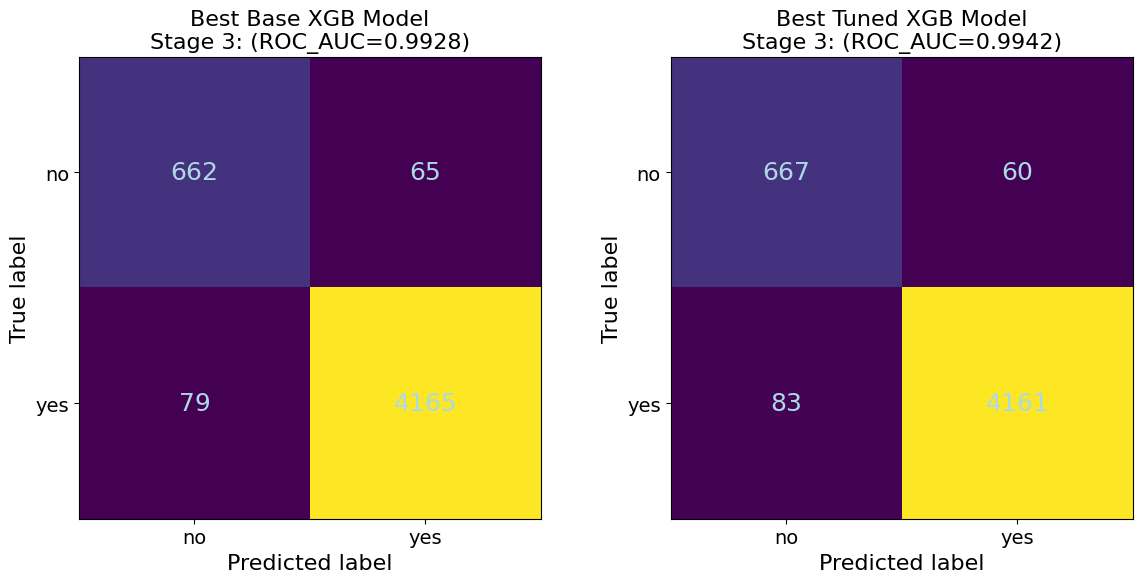

In [78]:
# Comparison Confusion Matrix
# Compute confusion matrices
# Comparison Confusion Matrix
# Compute confusion matrices
cm_comparison = confusion_matrix(y_val_s3, predictions_no_tunning_s3)
cm_comparison_best_param = confusion_matrix(y_val_s3, predictions_best_param_s3)

# Create display objects
disp_comparison = ConfusionMatrixDisplay(confusion_matrix=cm_comparison, display_labels=["no", "yes"])
disp_best_param = ConfusionMatrixDisplay(confusion_matrix=cm_comparison_best_param, display_labels=["no", "yes"])

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot confusion matrices
disp_comparison.plot(ax=axes[0], colorbar=False)
disp_best_param.plot(ax=axes[1], colorbar=False)

# Set titles with ROC_AUC info - FIX: Use the correct variable names
axes[0].set_title(f"Best Base XGB Model\nStage 3: (ROC_AUC={roc_auc_base_s3:.4f})", fontsize=16)
axes[1].set_title(f"Best Tuned XGB Model\nStage 3: (ROC_AUC={roc_auc_tuned_s3:.4f})", fontsize=16)

# Set axis labels with font size
axes[0].set_xlabel('Predicted label', fontsize=16)
axes[0].set_ylabel('True label', fontsize=16)
axes[1].set_xlabel('Predicted label', fontsize=16)
axes[1].set_ylabel('True label', fontsize=16)

# Remove grid lines
axes[0].grid(False)
axes[1].grid(False)

# Customize tick labels and cell fonts
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)
    for text in ax.texts:
        text.set_fontsize(18)
        text.set_color('lightblue')
        
plt.subplots_adjust(wspace=0.2, hspace=0.3)

plt.show()

### Comments

- Excellent performance of the models with the new data set. Get positive effect of the new feature RateModuleSuccess.
- The hyperparameter tuning has a modest effect on model performance compared to the default XGBoost configuration.
- The untuned model performs slightly worst in ROC-AUC (0.992813 vs 0.994196). However the differences with the best tuned model are negligible.
- Both models performed extremely well. More importantly, the improvement in performance is excellent for the negative class wich was a problem during stage 1 and 2.

### Shapley Analysis for Untuned Model

In [79]:
def shap_analysis(model, X, sample_size=1000, random_state=42):
    """Compute SHAP values with robust sampling and checks."""
    if len(X) == 0:
        raise ValueError("Input X is empty")
    
    explainer = shap.TreeExplainer(model)
    sample_size = min(max(sample_size, 10), len(X))  # Clamp sample_size
    
    if isinstance(X, pd.DataFrame):
        X_sample = X.sample(n=sample_size, random_state=random_state)
    else:
        X_sample = X[np.random.choice(len(X), size=sample_size, replace=False)]
    
    shap_values = explainer(X_sample)
    return shap_values, X_sample, explainer.expected_value



# Usage (training set is correct here)
shap_values_base_s3, X_sample_base_s3, expected_value_base_s3 = shap_analysis(xg_model_no_tunning_s3, X_train_s3)

# Find most surprising prediction (normalized)
shap_deviations_base_s3 = np.abs(shap_values_base_s3.values - expected_value_base_s3).sum(axis=1) / (np.abs(expected_value_base_s3) + 1e-9)
surprising_idx_base_s3 = np.argmax(shap_deviations_base_s3)

print(f"Most surprising observation (index {surprising_idx_base_s3}):")
print(f"  Deviation: {shap_deviations_base_s3[surprising_idx_base_s3]:.2%}")
print(f"  Features:\n{X_sample_base_s3.iloc[surprising_idx_base_s3]}")

Most surprising observation (index 505):
  Deviation: 24484.30%
  Features:
CourseLevel                                                             3.0
Age                                                                    27.0
Unauthorised_Absence_Ordinal                                            1.0
Autorised_Absence_Ordinal                                               1.0
RateModuleSuccess                                                       0.0
                                                                       ... 
ProgressionUniversity_University of Sheffield International College     0.0
ProgressionUniversity_University of Strathclyde                         0.0
ProgressionUniversity_University of Surrey                              0.0
ProgressionUniversity_University of Sussex                              0.0
ProgressionUniversity_VU Amsterdam                                      0.0
Name: 12669, Length: 241, dtype: float64


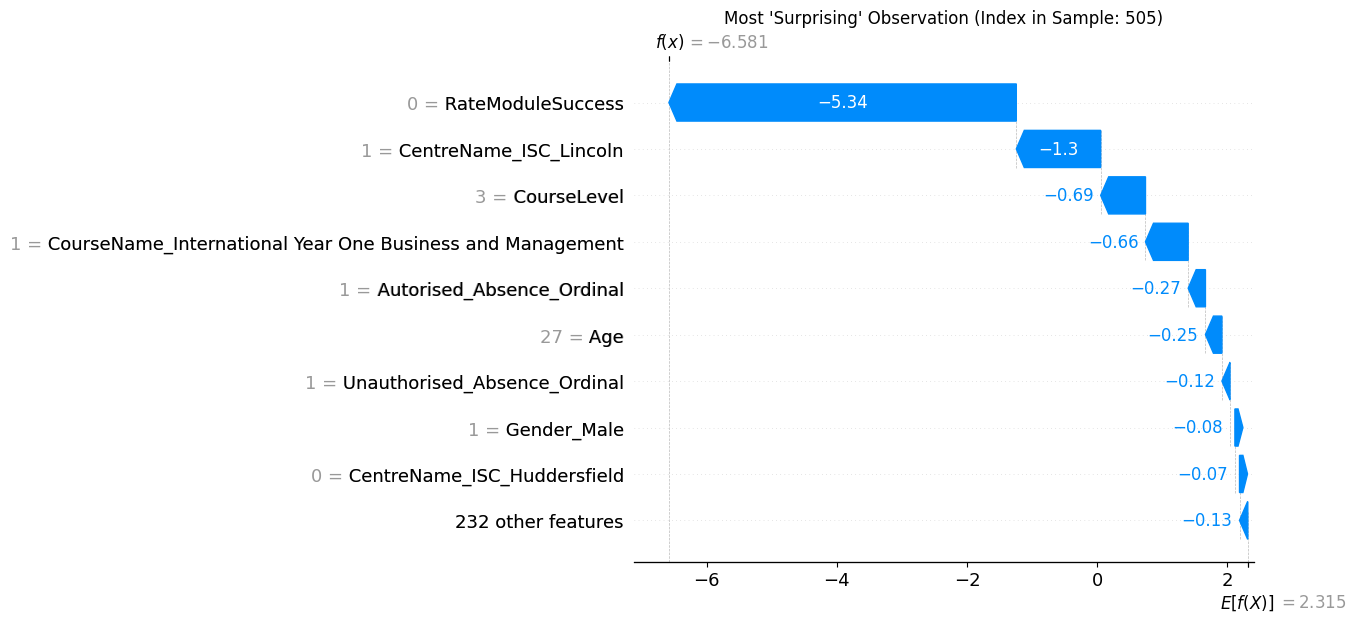

In [80]:
#Identifies the observation where the SHAP values deviate most from the expected value.
shap.plots.waterfall(shap_values_base_s3[surprising_idx_base_s3], show=False)
plt.title(f"Most 'Surprising' Observation (Index in Sample: {surprising_idx_base_s3})")
plt.show()

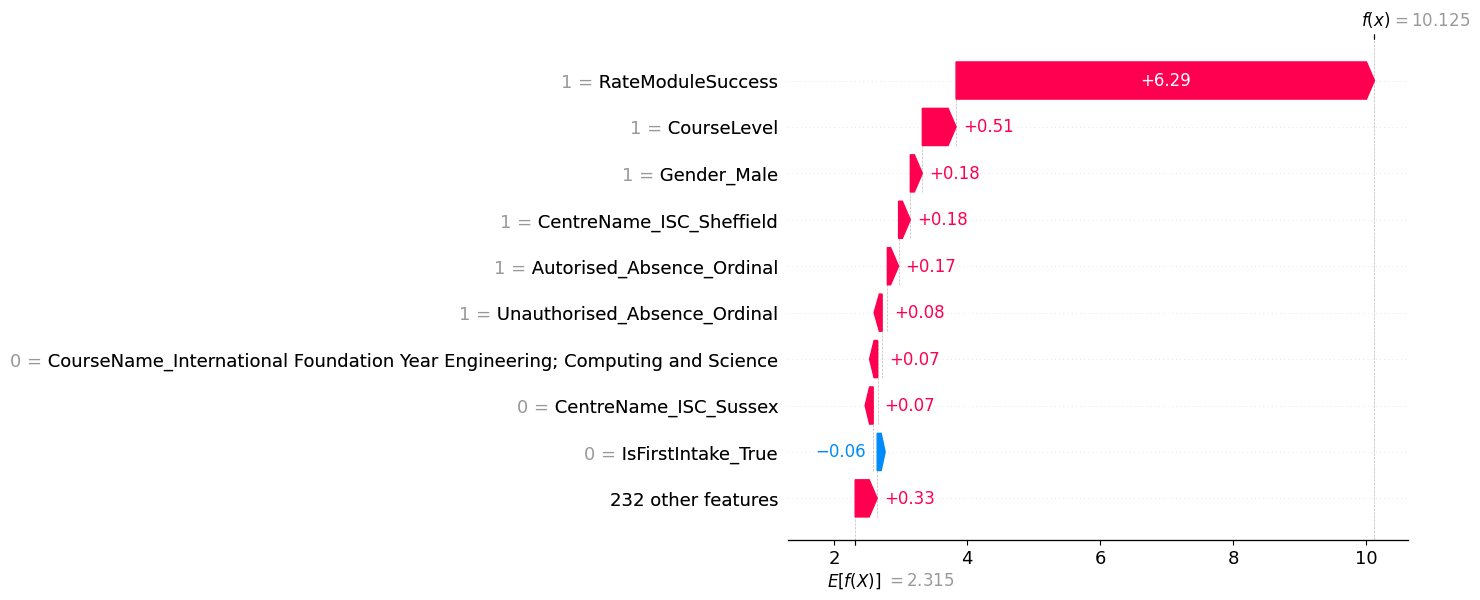

In [84]:
# Identifies the observation with the maximum predicted value from the model.
high_pred_idx_base_s3 = np.argmax(xg_model_no_tunning_s3.predict(X_train_s3))
explainer = shap.TreeExplainer(xg_model_no_tunning_s3)
shap_high_pred_base_s3 = explainer(X_train_s3.iloc[high_pred_idx_base_s3:high_pred_idx_base_s3+1])
shap.plots.waterfall(shap_high_pred_base_s3[0])

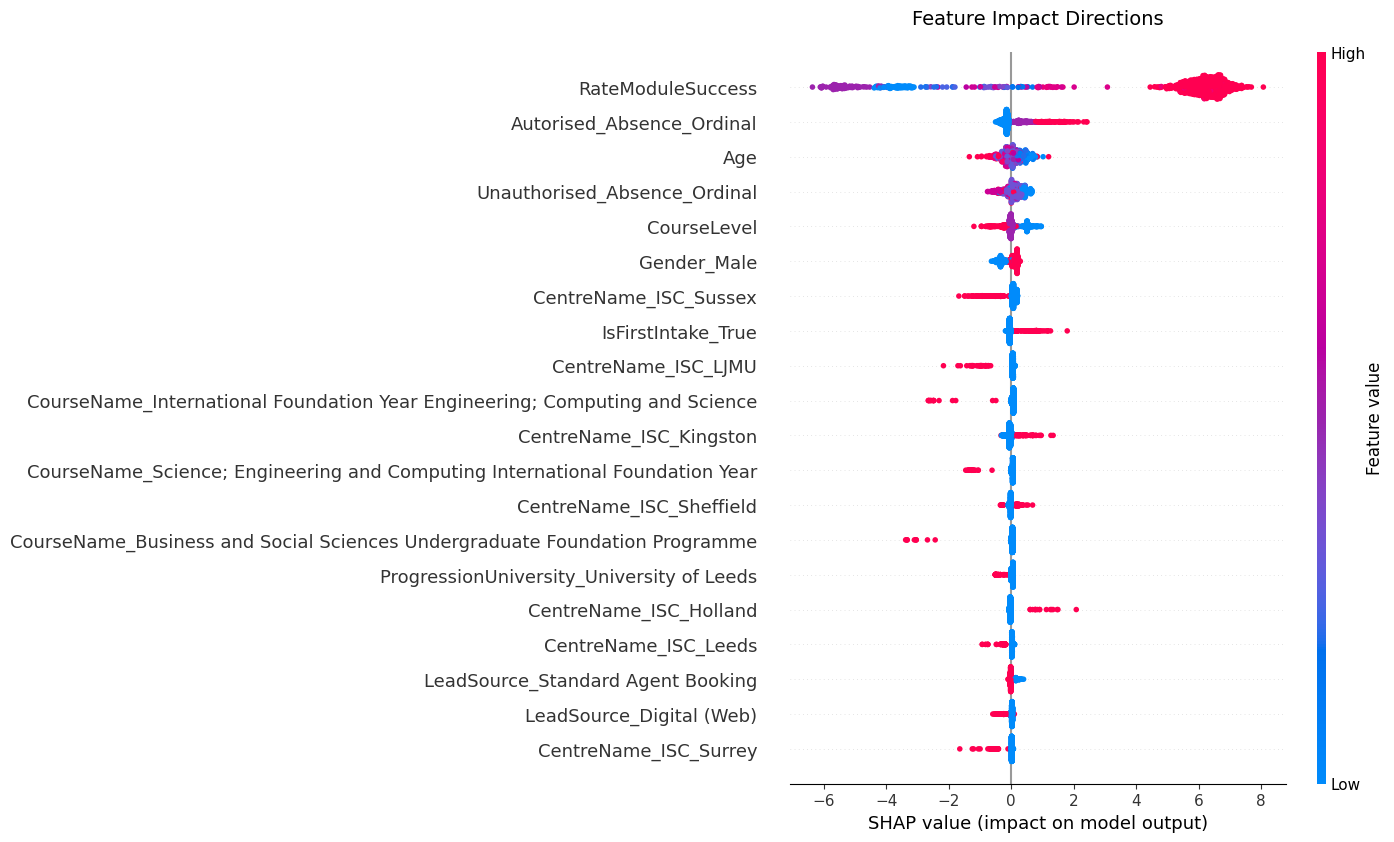

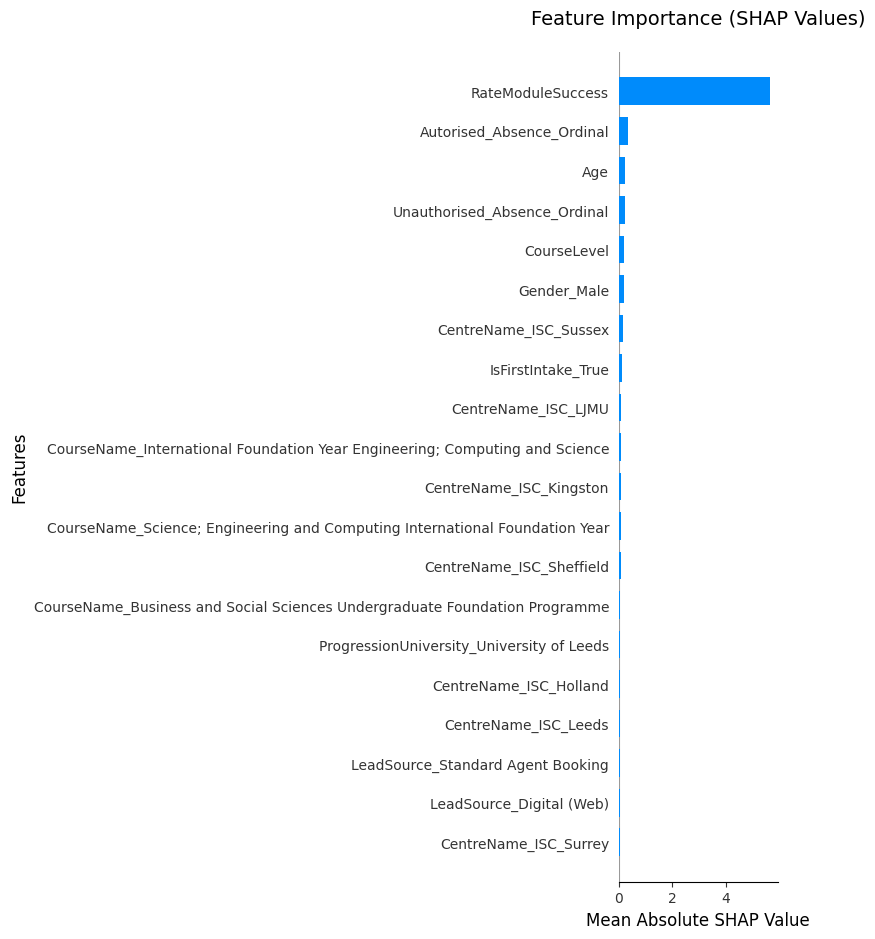

In [87]:
# Get SHAP values (unpack ALL return values)
shap_values_base_s3, X_sample_base_s3, expected_value_base_s3 = shap_analysis(
    xg_model_no_tunning_s3, 
    X_train_s3, 
    sample_size=1000, 
    random_state=42
)

# --------------------------------------------------
# 1. Feature Impact Directions (Beeswarm Plot)
# --------------------------------------------------
plt.close('all')  # Clear previous plots
shap.summary_plot(
    shap_values_base_s3,  # Use full Explanation object
    X_sample_base_s3,     # Sampled features
    show=False
)
plt.title("Feature Impact Directions", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2. Feature Importance (Bar Plot)
# --------------------------------------------------
plt.close('all')  # Clear previous plots for consistency
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_base_s3, 
    X_sample_base_s3, 
    plot_type="bar", 
    show=False
)
plt.title("Feature Importance (SHAP Values)", fontsize=14, pad=20)
plt.xlabel("Mean Absolute SHAP Value", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


### Shapley Analysis for Best Parameter Model

In [ ]:
# Get SHAP values for the best parameter model
def shap_analysis(model, X, sample_size=1000, random_state=42):
    """Compute SHAP values with robust sampling and checks."""
    if len(X) == 0:
        raise ValueError("Input X is empty")
    
    explainer = shap.TreeExplainer(model)
    sample_size = min(max(sample_size, 10), len(X))  # Clamp sample_size
    
    if isinstance(X, pd.DataFrame):
        X_sample = X.sample(n=sample_size, random_state=random_state)
    else:
        X_sample = X[np.random.choice(len(X), size=sample_size, replace=False)]
    
    shap_values = explainer(X_sample)
    return shap_values, X_sample, explainer.expected_value



# Usage (training set is correct here)
shap_values_best_param_s3, X_sample_best_param_s3, expected_value_best_param_s3 = shap_analysis(xg_model_best_param_s3, X_train_s3)

# Find most surprising prediction (normalized)
shap_deviations_best_param_s3 = np.abs(shap_values_best_param_s3.values - expected_value_best_param_s3).sum(axis=1) / (np.abs(expected_value_best_param_s3) + 1e-9)
surprising_idx_best_param_s3 = np.argmax(shap_deviations_best_param_s3)

print(f"Most surprising observation (index {surprising_idx_best_param_s3}):")
print(f"  Deviation: {shap_deviations_best_param_s3[surprising_idx_best_param_s3]:.2%}")
print(f"  Features:\n{X_sample_best_param_s3.iloc[surprising_idx_best_param_s3]}")

In [ ]:
# Identifies the observation where the SHAP values deviate most from the expected value.
shap.plots.waterfall(shap_values_best_param_s3[surprising_idx_best_param_s3], show=False)
plt.title(f"Most 'Surprising' Observation (Index in Sample: {surprising_idx_best_param_s3})")
plt.show()

In [ ]:
# Identifies the observation with the maximum predicted value from the model.
high_pred_idx_best_param_s3 = np.argmax(xg_model_best_param_s3.predict(X_train_s3))
explainer = shap.TreeExplainer(xg_model_best_param_s3)
shap_high_pred_best_param_s3 = explainer(X_train_s3.iloc[high_pred_idx_best_param_s3:high_pred_idx_best_param_s3+1])
shap.plots.waterfall(shap_high_pred_best_param_s3[0])

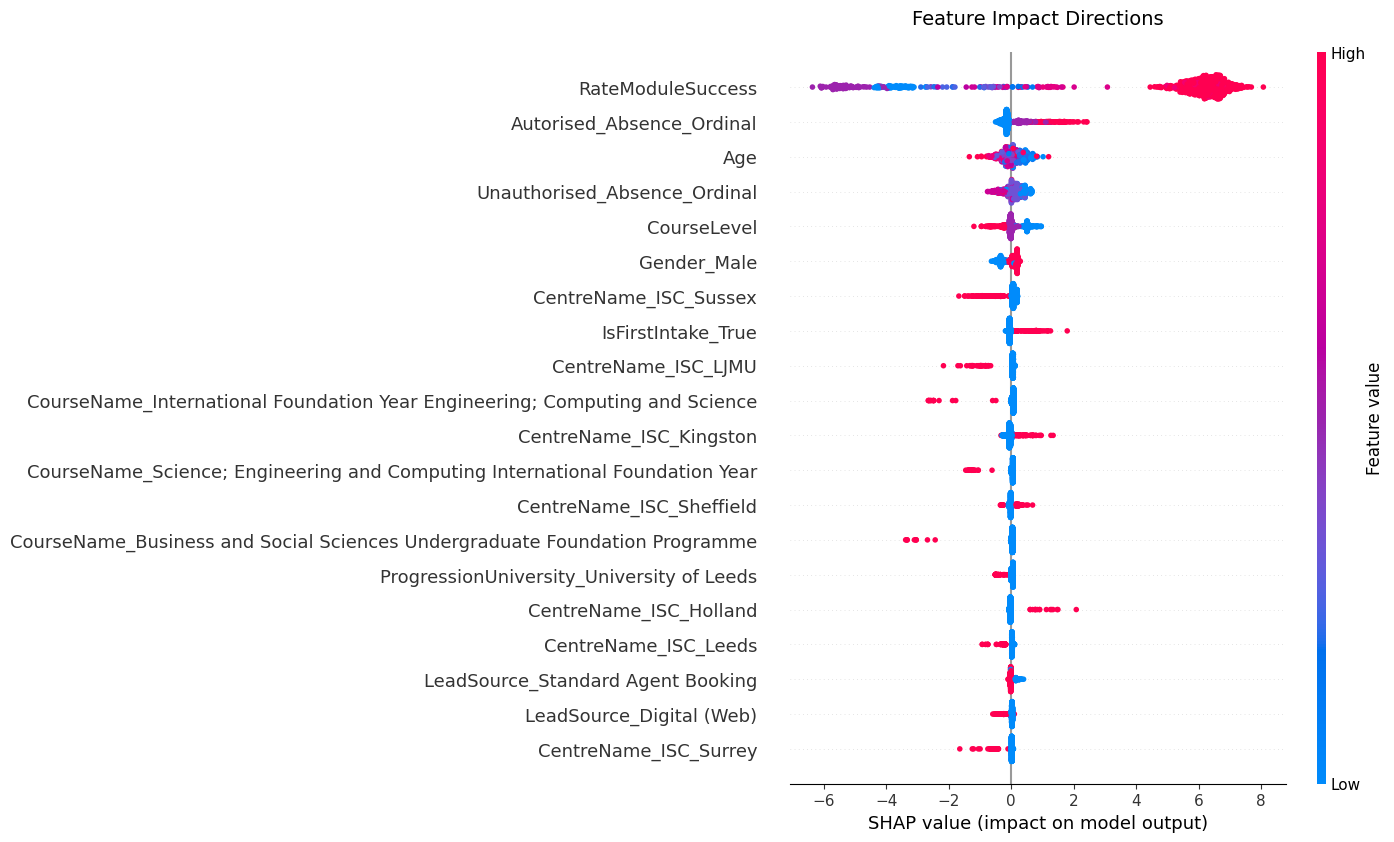

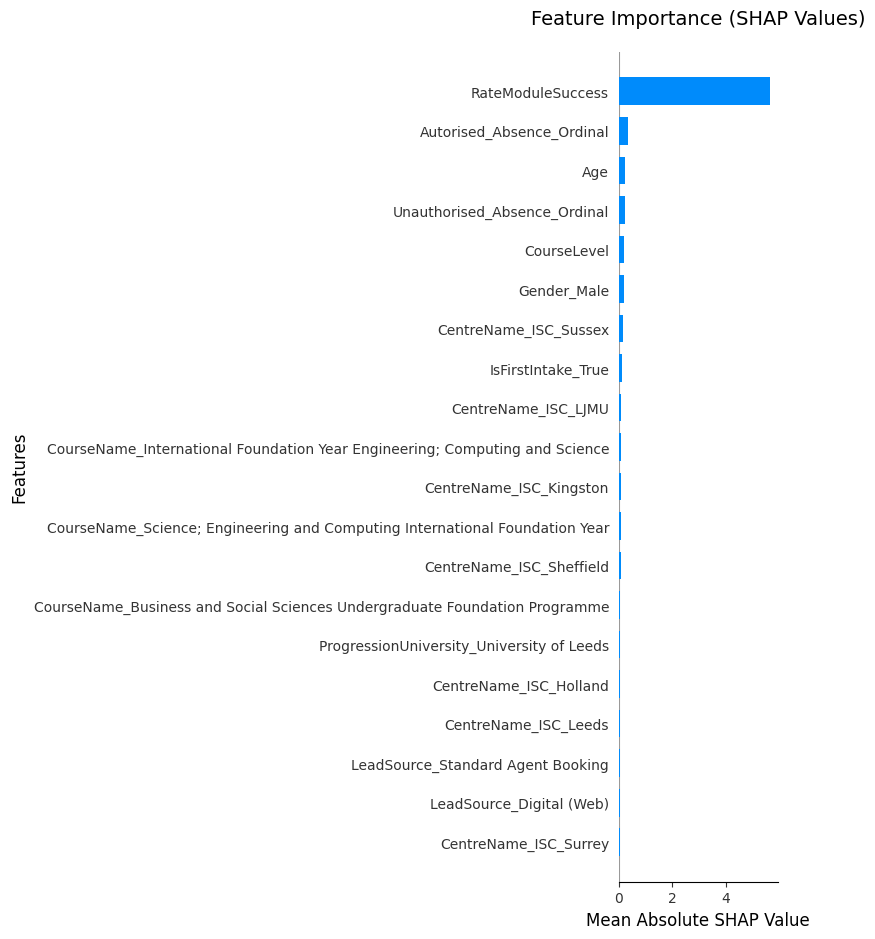

In [88]:
# Get SHAP values (unpack ALL return values)
shap_values_best_param_s3, X_sample_best_param_s3, expected_value_best_param_s3 = shap_analysis(
    xg_model_best_param_s3, 
    X_train_s3, 
    sample_size=1000, 
    random_state=42
)

# --------------------------------------------------
# 1. Feature Impact Directions (Beeswarm Plot)
# --------------------------------------------------
plt.close('all')  # Clear previous plots
shap.summary_plot(
    shap_values_base_s3,  # Use full Explanation object
    X_sample_base_s3,     # Sampled features
    show=False
)
plt.title("Feature Impact Directions", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2. Feature Importance (Bar Plot)
# --------------------------------------------------
plt.close('all')  # Clear previous plots for consistency
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_base_s3, 
    X_sample_base_s3, 
    plot_type="bar", 
    show=False
)
plt.title("Feature Importance (SHAP Values)", fontsize=14, pad=20)
plt.xlabel("Mean Absolute SHAP Value", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

#### Comments

1. Dominant Feature Effect

Problem: One feature's SHAP values are orders of magnitude larger than others.
Why it happens:
The dominant feature has such strong predictive power that other features' effects become negligible in comparison.
SHAP scales the y-axis to accommodate the dominant feature, squashing others into a flat line.

2. Categorical/Binary Features with Limited Values

Problem: If most features are binary (0/1) or categorical, their SHAP values cluster at discrete positions.
Visual Effect: Points stack vertically because many samples have identical SHAP values for low-importance features.

3. Model or Data Issues

Possible Causes:
Overfitting: The model relies too heavily on one feature.
Collinearity: Features are highly correlated, causing SHAP to attribute importance arbitrarily.
Zero Variance: Some features may have no predictive power (check with X.std()).


If one dominant feature is driving your model's predictions while test performance remains excellent, it’s not necessarily a problem—but it warrants careful consideration. Here’s how to assess whether this is acceptable or risky:

When It’s NOT a Problem

The Dominant Feature is Causally Relevant
Example: In a medical diagnosis model, a binary feature like Tested_Positive_for_Disease should dominate.
Action: Validate with domain experts to confirm the feature’s real-world importance.
Your Goal is Pure Prediction (Not Inference)
If you only care about accuracy (e.g., recommendation systems), and the model generalizes well to the test set, the dominance may be fine.
Action: Monitor performance over time to detect drift in the dominant feature’s relationship.
The Feature is Redundant with Others
SHAP might arbitrarily assign importance to one correlated feature (e.g., Age vs. Yearly_Income in credit scoring).
Action: Check correlations (df.corr())—if the dominant feature is a proxy for others, it’s explainable.
When It IS a Problem

Data Leakage
The dominant feature may leak information about the target (e.g., including Future_Revenue to predict Current_Profit).
Test: Remove the feature and see if performance drops drastically. If not, it was likely a leak.
Overfitting to Noise
Even with good test performance, the model may be exploiting spurious patterns (e.g., a unique ID field dominating predictions).
Test: Use adversarial validation—train a model to distinguish train/test sets. If it succeeds, your data is non-stationary.
Deployment Risks
If the dominant feature is unstable (e.g., User_IP_Address in a churn model), the model may fail in production.
Action: Stress-test with synthetic data where the dominant feature is perturbed.